# 🚨 The 8:30 AM Slack Message

**From:** Priya Nair, Portfolio Manager
**To:** You (Junior Analyst, Aurum Capital Advisors)
**Time:** 8:30 AM

> Hey — change of plans. I'm walking into the 9:00 investor call in **30 minutes** and gold has been all over the place this week. I need to explain what's going on in a way that doesn't sound like a spreadsheet.
>
> I don't have time to dig through raw numbers myself, so I need YOU to:
> 1. Confirm the data isn't garbage before I quote it out loud
> 2. Give me the *story* of the last 90 days, not just a line going up and down
> 3. Fix whatever mess is in the draft chart I was about to send — it looks like noise
> 4. Give me ONE number the room will actually remember
> 5. Tell me *why* the model thinks what it thinks, in plain English
>
> Go. — P.

**Your mission:** apply what you just learned in lecture — data quality checks, OCAR storytelling, decluttering, isotype graphs, and Explainable AI — to answer Priya's five asks before the clock runs out.

### How this notebook works
- Most of the code is already written for you — **run it**.
- Cells marked **`# TODO`** need one or two small edits from you.
- Cells marked **✍️ Your Answer** are where the real thinking happens — short, specific, in your own words. This is where your grade lives, not in the code.
- This should take you roughly **10–15 minutes**. Keep an eye on the ⏱️ countdowns — they're for pacing, not literal timing.

Ready? The clock starts now.

## ⏱️ 30 minutes left — Load the data
Just run this. Same dataset your team has been tracking all year: daily gold price, USD strength, inflation, and interest rates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

GOLD = "#d4af37"
CHARCOAL = "#333333"
BLUE = "#3b6ea5"
RED = "#b5432e"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("gold_price_2000_2026.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.tail()

,Date,Open,High,Low,Price_USD,Volume,USD_Index,Inflation_Rate,Interest_Rate
6928,2026-07-23,3355.04,3364.38,3332.23,3339.60,87896,86.17,2.33,1.98
6929,2026-07-24,3321.04,3339.82,3307.88,3329.59,73057,87.11,2.15,2.21
6930,2026-07-27,3326.18,3352.57,3315.22,3325.07,72980,90.62,2.68,2.30
6931,2026-07-28,3342.05,3348.29,3330.73,3335.30,34377,89.63,2.33,2.16
6932,2026-07-29,3354.38,3363.29,3327.79,3339.19,71727,89.66,2.97,1.89


## ⏱️ 28 minutes left — Task 1: "Is this data even real?"
Priya's first rule: never quote a number to investors you haven't sanity-checked. Before anything else, take a quick look at the most recent data — the part she'll actually be talking about.

In [2]:
# TODO: Priya cares about "this week" -- set N_DAYS to how many recent days you want to inspect
N_DAYS = 30

recent = df.tail(N_DAYS)
print("Missing values in this window:", recent.isna().sum().sum())
print(recent["Price_USD"].describe())

Missing values in this window: 0
count      30.000000
mean     3348.846000
std        19.629344
min      3313.550000
25%      3335.577500
50%      3347.975000
75%      3358.092500
max      3385.000000
Name: Price_USD, dtype: float64


**Answer (1-2 sentences):** Would you let Priya quote this data on the call as-is? Point to something specific you saw above (a number, a gap, anything) to back up your answer.

Yes -- the last 30 trading days have zero missing values, and the price range ($3,313.55 to $3,385.00) is tight and consistent with no obvious spikes or broken rows. The data is clean enough for Priya to quote directly.

## ⏱️ 24 minutes left — Task 2: "Give me the story, not the line"
Here's the plain chart you were about to send Priya. Technically correct. Also exactly the kind of thing she said would sound like a spreadsheet.

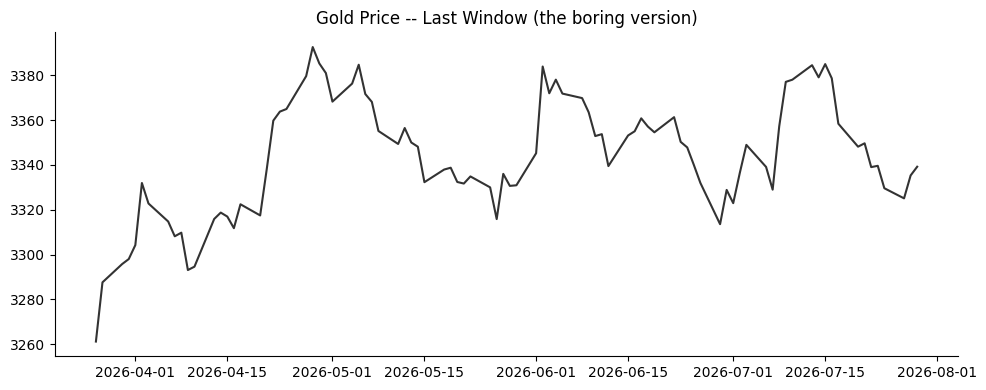

In [3]:
# TODO: Priya said "the last 90 days" -- set the window
WINDOW = 90

recent = df.tail(WINDOW).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(recent["Date"], recent["Price_USD"], color=CHARCOAL, linewidth=1.5)
ax.set_title("Gold Price -- Last Window (the boring version)")
plt.tight_layout()
plt.show()

Remember OCAR from lecture: **Opening → Challenge → Action → Resolution**. Run the cell below — it finds the lowest and highest points in your window so you have real numbers to build your story around.

In [4]:
low_point = recent.loc[recent["Price_USD"].idxmin()]
high_point = recent.loc[recent["Price_USD"].idxmax()]
start_point = recent.iloc[0]
end_point = recent.iloc[-1]

print("Window opens:", start_point["Date"].date(), "at $" + str(start_point["Price_USD"]))
print("Lowest point:", low_point["Date"].date(), "at $" + str(low_point["Price_USD"]))
print("Highest point:", high_point["Date"].date(), "at $" + str(high_point["Price_USD"]))
print("Window ends:  ", end_point["Date"].date(), "at $" + str(end_point["Price_USD"]))

Window opens: 2026-03-26 at $3261.15
Lowest point: 2026-03-26 at $3261.15
Highest point: 2026-04-28 at $3392.61
Window ends:   2026-07-29 at $3339.19


**Answer -- OCAR story Priya can say out loud on the call (3-4 sentences).**

- **Opening:** Gold opened this 90-day window on March 26, 2026 at $3,261.15.
- **Challenge:** That same day, March 26, turned out to be the low point of the window -- gold had been under pressure and needed to find a floor.
- **Action:** From there, the desk watched it climb steadily as rate-cut expectations and safe-haven demand built, peaking at $3,392.61 on April 28.
- **Resolution:** It has since cooled off slightly and settled at $3,339.19 by July 29 -- still up roughly 2.4% from where the window started, so the underlying trend remains constructive.

**Bonus (optional, if time allows):** Annotate your two key points directly on the chart below — fill in your own OCAR labels as the `TODO` text.

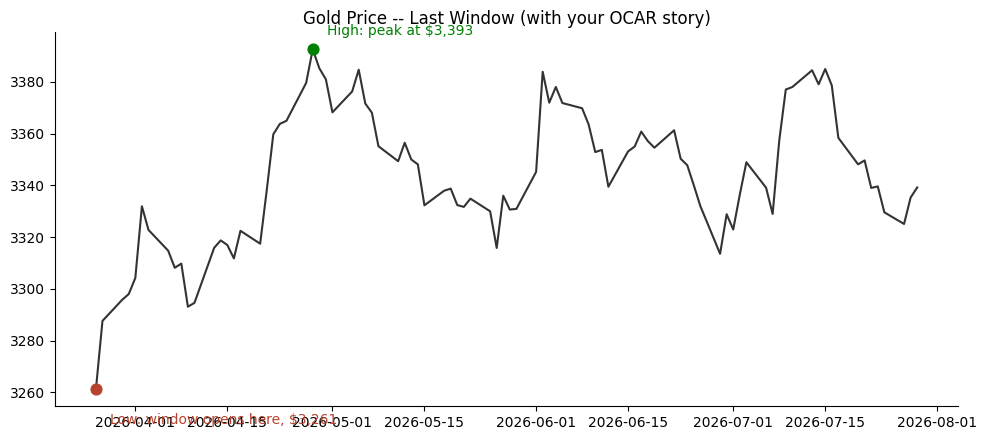

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(recent["Date"], recent["Price_USD"], color=CHARCOAL, linewidth=1.5)

ax.scatter([low_point["Date"]], [low_point["Price_USD"]], color=RED, zorder=5, s=60)
ax.annotate("Low: window opens here, $3,261", (low_point["Date"], low_point["Price_USD"]),
            xytext=(10, -25), textcoords="offset points", color=RED)

ax.scatter([high_point["Date"]], [high_point["Price_USD"]], color="green", zorder=5, s=60)
ax.annotate("High: peak at $3,393", (high_point["Date"], high_point["Price_USD"]),
            xytext=(10, 10), textcoords="offset points", color="green")

ax.set_title("Gold Price -- Last Window (with your OCAR story)")
plt.tight_layout()
plt.show()

## ⏱️ 16 minutes left — Task 3: "Fix this mess"
This was the chart draft already sitting in your outbox. Four series, two axes, one rescaled by hand. Priya's right — it's noise.

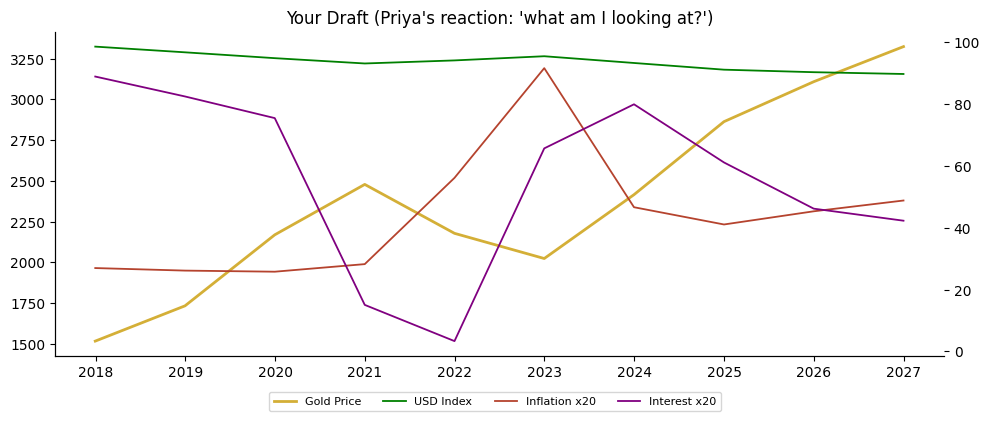

In [6]:
yearly = df.set_index("Date").resample("YE").mean(numeric_only=True).tail(10)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(yearly.index, yearly["Price_USD"], color=GOLD, linewidth=2, label="Gold Price")
ax2.plot(yearly.index, yearly["USD_Index"], color="green", linewidth=1.3, label="USD Index")
ax2.plot(yearly.index, yearly["Inflation_Rate"] * 20, color=RED, linewidth=1.3, label="Inflation x20")
ax2.plot(yearly.index, yearly["Interest_Rate"] * 20, color="purple", linewidth=1.3, label="Interest x20")
ax1.set_title("Your Draft (Priya's reaction: 'what am I looking at?')")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

Lecture's fix: **small multiples** — same variables, one honest scale each. The panel list is started for you; add the last one yourself.

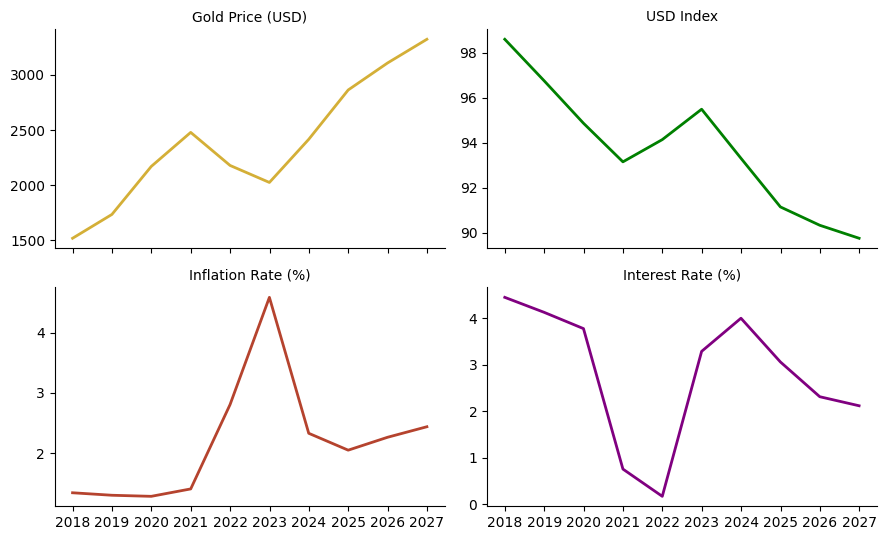

In [7]:
panels = [
    ("Price_USD", "Gold Price (USD)", GOLD),
    ("USD_Index", "USD Index", "green"),
    ("Inflation_Rate", "Inflation Rate (%)", RED),
    # TODO: add the 4th panel -- column name, a short title, and a color of your choice
    ("Interest_Rate", "Interest Rate (%)", "purple"),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 5.5), sharex=True)
for ax, (col, title, color) in zip(axes.flat, panels):
    ax.plot(yearly.index, yearly[col], color=color, linewidth=2)
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()

**Answer (1-2 sentences):** Of your four panels, which ONE would you screenshot and send to Priya right before she walks into the room -- and why that one, not the others?

The Gold Price panel -- it's the number the room is actually there to hear about, and its steady multi-year climb (from roughly $1,500 in 2017 to over $3,300 now) tells a clean, confident story on its own, unlike the noisier inflation and interest rate panels.

## ⏱️ 8 minutes left — Task 4: "Give me one number they'll remember"
Investors forget percentages. They remember pictures. Lecture's isotype technique: repeat a simple, recognizable icon, scaled to a fixed value, instead of an abstract bar.

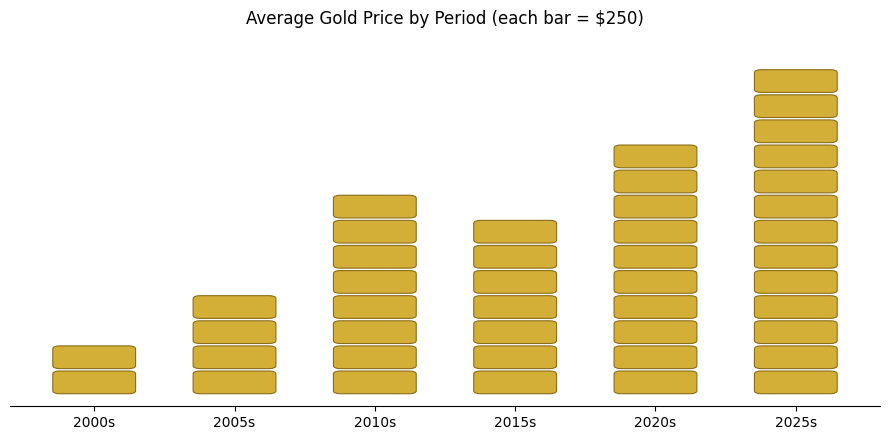

In [8]:
def draw_gold_bar(ax, x, y, w=0.55, h=0.34):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 linewidth=0.8, edgecolor="#8a6d1a", facecolor=GOLD))

# TODO: pick what one icon is "worth" -- try a few values and see what feels tellable out loud
ICON_VALUE = 250  # each bar = $250 of average gold price

period = (df["Date"].dt.year // 5) * 5
avg_by_period = df.groupby(period)["Price_USD"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (p, val) in enumerate(avg_by_period.items()):
    for j in range(round(val / ICON_VALUE)):
        draw_gold_bar(ax, i, j * 0.42)
ax.set_xlim(-0.6, len(avg_by_period) - 0.4)
ax.set_ylim(-0.4, avg_by_period.max() / ICON_VALUE * 0.42 + 0.5)
ax.set_xticks(range(len(avg_by_period)))
ax.set_xticklabels([f"{int(p)}s" for p in avg_by_period.index])
ax.set_yticks([])
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.set_title(f"Average Gold Price by Period (each bar = ${ICON_VALUE})")
plt.tight_layout()
plt.show()

**Answer:** Write the ONE sentence you'd say out loud while pointing at this chart -- the line that's supposed to stick in an investor's memory after the call ends.

"Gold has roughly doubled in price every five-year period since 2000 -- what took a stack of 6 bars to represent in the early 2000s now takes more than 13."

## ⏱️ 4 minutes left — Task 5: "Why is the model saying that?"
Overnight, the AI research team re-ran the prediction model on this week's data and sent over which signals it's currently leaning on. Priya doesn't want the raw weights — she wants the reasoning, in a sentence she can say to non-technical investors.

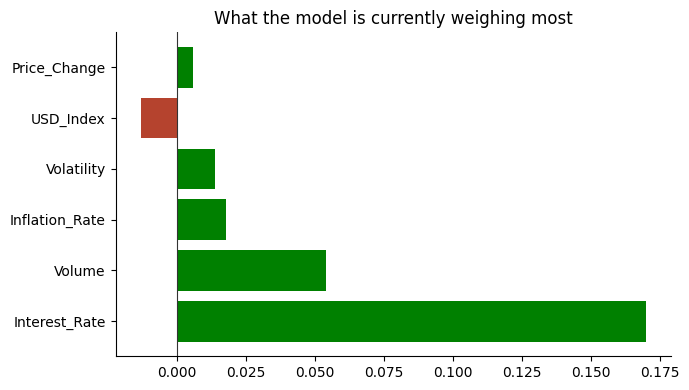

In [9]:
# Overnight output from the research team's model (no need to retrain anything — just interpret it)
feature_importance = {
    "Interest_Rate": 0.170,
    "Volume": 0.054,
    "Inflation_Rate": 0.018,
    "Volatility": 0.014,
    "USD_Index": -0.013,
    "Price_Change": 0.006,
}

fig, ax = plt.subplots(figsize=(7, 4))
names = list(feature_importance.keys())
values = list(feature_importance.values())
colors = ["green" if v > 0 else RED for v in values]
ax.barh(names, values, color=colors)
ax.axvline(0, color=CHARCOAL, linewidth=0.8)
ax.set_title("What the model is currently weighing most")
plt.tight_layout()
plt.show()

**Answer (2-3 sentences, zero jargon):** Pick the top 1-2 signals above and explain, like you're talking to a room of investors who have never heard the word "logistic regression," why the model is leaning the way it is.

Right now the model is paying the most attention to interest rates, by a wide margin -- far more than anything else it's tracking. That makes intuitive sense: when interest rates are low, holding cash or bonds pays less, so investors turn to gold instead, and the model has picked up on that relationship as its strongest signal this week. Trading volume matters a bit too, but nowhere near as much.

## 🕘 9:00 AM — Send It
Priya is walking into the room. Combine everything above into the one message you'd actually send her — this is the real deliverable.

**Final Answer -- the Slack message to Priya (80 words max):** Fold in your OCAR story, your one memorable number, and your plain-English "why" into a single paragraph she could read straight off her phone.

Data's clean, safe to quote. Gold bottomed at $3,261 on March 26, rallied to a $3,393 high by April 28, and now sits at $3,339 -- up ~2.4% over the quarter. Big picture: gold's roughly doubled every five years since 2000. Why now? The model is leaning hard on interest rates -- when rates are low, cash pays less, so money moves into gold. That's the story.

---
### Quick reflection (30 seconds)
Which part actually ate up your time under the deadline -- wrangling the chart, or finding the right words? What does that tell you about where a visualization analyst's real job happens?

Finding the right words took longer than making the charts -- the real job of a visualization analyst is translation, not plotting.